Title:
Customer Segmentation and Customer Analytics Using K-Means Clustering

Objective:
To classify customers into different segments based on demographic and behavioral data, analyze purchasing patterns, and generate targeted business insights

STEP 1:IMPORT LIBRARIES

In [140]:
# Data Processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

STEP 2:UPLOAD DATA

In [141]:
from google.colab import files

uploaded = files.upload()

Saving customer_data_500.xlsx to customer_data_500 (5).xlsx


STEP 3:LOAD DATA

In [142]:
# Load dataset
df = pd.read_excel('customer_data_500.xlsx')

# Show first rows
df.head()

,Customer ID,Age,Gender,Location,Income,Purchase Amount,Purchase Frequency,Preferred Product Category
0,C001,69,Female,Chennai,303444,1783,Weekly,Fashion
1,C002,56,Non-binary,Bangalore,1870226,17137,Quarterly,Books
2,C003,45,Female,Bangalore,2455845,5220,Monthly,Kitchenware
3,C004,28,Female,Pune,2024992,17158,Quarterly,Fashion
4,C005,21,Male,Delhi,743814,15993,Weekly,Fashion


STEP 4:

  STATEMENT 1:UNDERSTAND OF DATA

In [143]:
# Dataset shape
print("Rows and Columns:")
print(df.shape)

# Information
df.info()




Rows and Columns:
(500, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Customer ID                 500 non-null    object
 1   Age                         500 non-null    int64 
 2   Gender                      500 non-null    object
 3   Location                    500 non-null    object
 4   Income                      500 non-null    int64 
 5   Purchase Amount             500 non-null    int64 
 6   Purchase Frequency          500 non-null    object
 7   Preferred Product Category  500 non-null    object
dtypes: int64(3), object(5)
memory usage: 31.4+ KB


STEP 4:

STATEMENT 2:DATA SHAPE AND INFO

In [144]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Customer ID                 500 non-null    object
 1   Age                         500 non-null    int64 
 2   Gender                      500 non-null    object
 3   Location                    500 non-null    object
 4   Income                      500 non-null    int64 
 5   Purchase Amount             500 non-null    int64 
 6   Purchase Frequency          500 non-null    object
 7   Preferred Product Category  500 non-null    object
dtypes: int64(3), object(5)
memory usage: 31.4+ KB


STEP 4:

STATEMENT 3:DESCRIBE OF DATA

In [145]:
df.describe()

,Age,Income,Purchase Amount
count,500.000000,5.000000e+02,500.000000
mean,45.284000,1.392284e+06,9769.716000
std,15.352744,6.569016e+05,5668.425059
min,18.000000,3.034440e+05,539.000000
25%,31.750000,8.482738e+05,4619.750000
50%,47.000000,1.412410e+06,9845.000000
75%,58.000000,1.963730e+06,14707.750000
max,70.000000,2.495127e+06,19998.000000


STEP 4:

STATEMENT 4:NULL DATA

In [146]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Location,0
Income,0
Purchase Amount,0
Purchase Frequency,0
Preferred Product Category,0


STEP 5:DATA CLEANING

In [147]:
# Remove missing values
df = df.dropna()

# The following lines are commented out as the required columns (Year_Birth, MntWines, etc.)
# are not present in the 'customer_data_500.xlsx' dataset currently loaded.
# df["Age"] = 2026 - df["Year_Birth"]

# Total Spending
# df["Total_Spending"] = (
#     df["MntWines"] +
#     df["MntFruits"] +
#     df["MntMeatProducts"] +
#     df["MntFishProducts"] +
#     df["MntSweetProducts"] +
#     df["MntGoldProds"]
# )

# Total Children
# df["Children"] = (
#     df["Kidhome"] +
#     df["Teenhome"]
# )

df.head()

,Customer ID,Age,Gender,Location,Income,Purchase Amount,Purchase Frequency,Preferred Product Category
0,C001,69,Female,Chennai,303444,1783,Weekly,Fashion
1,C002,56,Non-binary,Bangalore,1870226,17137,Quarterly,Books
2,C003,45,Female,Bangalore,2455845,5220,Monthly,Kitchenware
3,C004,28,Female,Pune,2024992,17158,Quarterly,Fashion
4,C005,21,Male,Delhi,743814,15993,Weekly,Fashion


STEP 6:FEATURES FOR  CUSTOMER SEGMENTION

In [148]:
features = [
    "Income",
    "Age",
    "Purchase Amount"
]

X = df[features]

STEP 7:NORMALIZE OF DATA

In [149]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.65919916  1.54628718 -1.41039436]
 [ 0.72829869  0.698685    1.3010073 ]
 [ 1.62067816 -0.01851685 -0.80344584]
 [ 0.96413462 -1.1269197   1.30471574]
 [-0.98815339 -1.58332087  1.09898544]]


STEP 8:OPTIMAL NUMBER OF CLUSTERS(ELBOW METHOD)

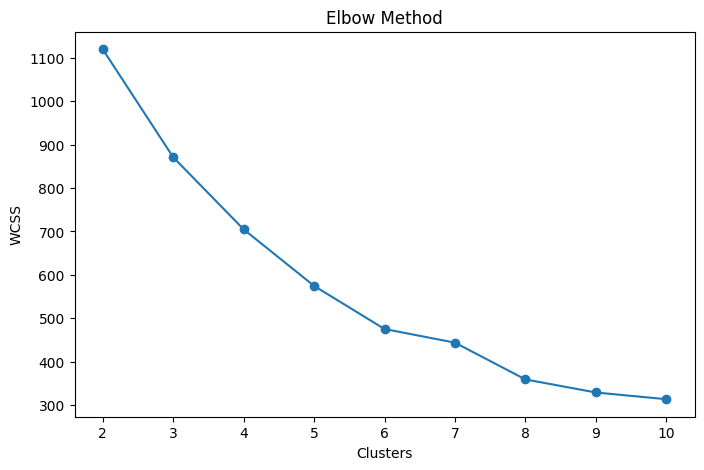

In [150]:
wcss=[]

for i in range(2,11):

    model=KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

STEP 9:K-MEANS CLUSTERING

In [151]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer ID,Age,Gender,Location,Income,Purchase Amount,Purchase Frequency,Preferred Product Category,Cluster
0,C001,69,Female,Chennai,303444,1783,Weekly,Fashion,0
1,C002,56,Non-binary,Bangalore,1870226,17137,Quarterly,Books,2
2,C003,45,Female,Bangalore,2455845,5220,Monthly,Kitchenware,3
3,C004,28,Female,Pune,2024992,17158,Quarterly,Fashion,1
4,C005,21,Male,Delhi,743814,15993,Weekly,Fashion,1


STEP 10:EVALUATE CLUSTERING

In [152]:
score = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("Silhouette Score:",score)

Silhouette Score: 0.26775916141182027


STEP 11:REDUCE DIMENSIONS FOR VISUALIZATION(PCA)

In [153]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(X_scaled)

df["PCA1"] = reduced[:,0]
df["PCA2"] = reduced[:,1]

STEP 12:VISUALIZE CUSTOMER SEGMENTS

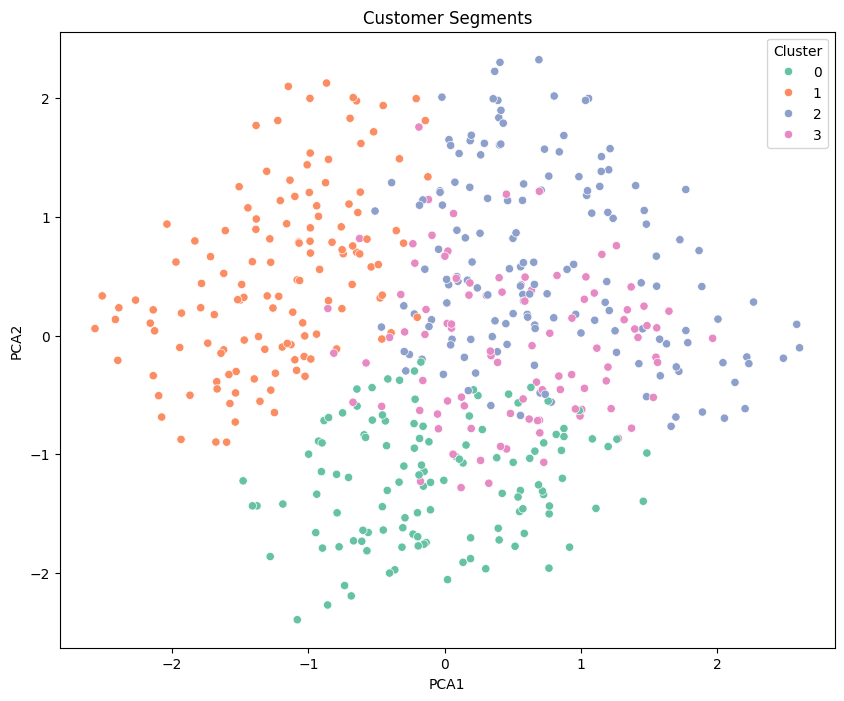

In [154]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    data=df
)

plt.title(
    "Customer Segments"
)

plt.show()

STEP 13:ANALYZE CUSTOMER CHARACTERISTIC

In [155]:
cluster_summary = df.groupby(
    "Cluster"
)[
features
].mean()

cluster_summary

,Income,Age,Purchase Amount
Cluster,,,
0,7.924001e+05,44.966667,5001.025000
1,1.123126e+06,35.653846,15910.415385
2,1.711152e+06,60.590909,10986.655844
3,1.995107e+06,34.166667,5462.875000


STEP 14:VISUALIZE OF SEGMENT COMPARISON

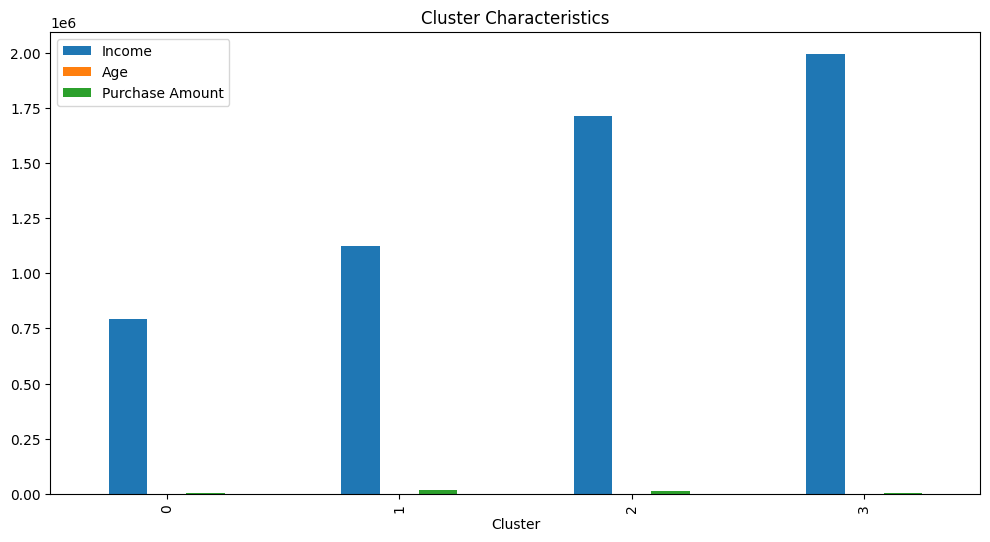

In [156]:
cluster_summary.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Cluster Characteristics"
)

plt.show()

STEP 15:ANALYTICS OF  CUSTOMER PURCHASE PREFERENCES

In [157]:
purchase_features = [
    "Purchase Amount"
]

purchase_analysis = (
    df.groupby("Cluster")
    [purchase_features]
    .mean()
)

print(
    purchase_analysis.round(2)
)

         Purchase Amount
Cluster                 
0                5001.02
1               15910.42
2               10986.66
3                5462.88


STEP 16:HEATMAP FOR CUSTOMER PREFERENCE

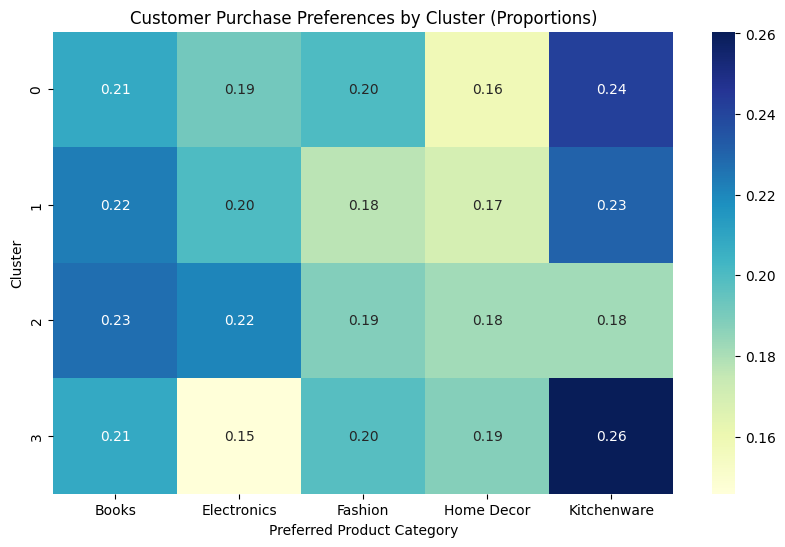

In [158]:
purchase_analysis = pd.crosstab(df['Cluster'], df['Preferred Product Category'], normalize='index')

plt.figure(
    figsize=(10,6)
)

sns.heatmap(
    purchase_analysis,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title(
    "Customer Purchase Preferences by Cluster (Proportions)"
)

plt.show()

STEP 17:SEGMENT LABELS

In [159]:
segment_names = {
    0:"Premium Customers",
    1:"Budget Customers",
    2:"Regular Customers",
    3:"Online Customers"
}

df["Segment"] = (
    df["Cluster"]
    .map(segment_names)
)

print(
    df[
        ["Cluster","Segment"]
    ].head()
)

   Cluster            Segment
0        0  Premium Customers
1        2  Regular Customers
2        3   Online Customers
3        1   Budget Customers
4        1   Budget Customers


STEP 18:TARGETED INSIGHTS

In [160]:
for segment in df["Segment"].unique():

    print("\n",segment)

    if segment=="Premium Customers":
        print(
            "- Launch VIP programs"
        )

    elif segment=="Budget Customers":
        print(
            "- Offer discounts"
        )

    elif segment=="Online Customers":
        print(
            "- Promote digital campaigns"
        )

    else:
        print(
            "- Improve customer retention"
        )


 Premium Customers
- Launch VIP programs

 Regular Customers
- Improve customer retention

 Online Customers
- Promote digital campaigns

 Budget Customers
- Offer discounts


STEP 19:FINAL RESULT

In [161]:
df.to_csv(
    "Final_Customer_Segmentation.csv",
    index=False
)

print(
    "Project Completed Successfully"
)

Project Completed Successfully


REPORT:

Thus,The Customer data was successfully segmented into meaningful groups using K-Means clustering, enabling analysis of customer behavior, purchasing patterns, and targeted business insights through data-driven decision-making.